In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("ShadowFox Task 2 - E-Commerce Analysis")
print("Libraries imported successfully!")

ShadowFox Task 2 - E-Commerce Analysis
Libraries imported successfully!


In [23]:
clean_df.to_csv(
    "../dashboard/clean_ecommerce_data.csv",
    index=False
)

print("Clean dataset exported successfully!")

Clean dataset exported successfully!


In [24]:
import os

print(os.listdir("../data"))

['online+retail+ii', 'online+retail+ii.zip']


In [108]:
rfm.reset_index().to_csv(
    "../dashboard/rfm_customer_segments.csv",
    index=False
)

print("RFM customer segments exported successfully!")

RFM customer segments exported successfully!


In [25]:
import os

print(os.listdir("../data/online+retail+ii"))

['online_retail_II.xlsx']


In [26]:
file_path = "../data/online+retail+ii/online_retail_II.xlsx"

excel_file = pd.ExcelFile(file_path)

print(excel_file.sheet_names)

['Year 2009-2010', 'Year 2010-2011']


In [27]:
print(excel_file.sheet_names)


['Year 2009-2010', 'Year 2010-2011']


In [28]:
df_2009_2010 = pd.read_excel(
    file_path,
    sheet_name="Year 2009-2010"
)

df_2010_2011 = pd.read_excel(
    file_path,
    sheet_name="Year 2010-2011"
)

print("2009-2010 shape:", df_2009_2010.shape)
print("2010-2011 shape:", df_2010_2011.shape)

2009-2010 shape: (525461, 8)
2010-2011 shape: (541910, 8)


In [29]:
df = pd.concat(
    [df_2009_2010, df_2010_2011],
    ignore_index=True
)

print("Combined dataset shape:", df.shape)

Combined dataset shape: (1067371, 8)


In [30]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [31]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 1067371
Columns: 8


In [32]:
print(df.columns.tolist())

['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country']


In [33]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [34]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   Invoice      1067371 non-null  object        
 1   StockCode    1067371 non-null  object        
 2   Description  1062989 non-null  object        
 3   Quantity     1067371 non-null  int64         
 4   InvoiceDate  1067371 non-null  datetime64[us]
 5   Price        1067371 non-null  float64       
 6   Customer ID  824364 non-null   float64       
 7   Country      1067371 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 78.8+ MB


In [35]:
missing = df.isnull().sum()

print(missing)

Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64


In [36]:
missing_percent = (df.isnull().sum() / len(df)) * 100

print(missing_percent.sort_values(ascending=False))

Customer ID    22.766873
Description     0.410541
StockCode       0.000000
Invoice         0.000000
Quantity        0.000000
InvoiceDate     0.000000
Price           0.000000
Country         0.000000
dtype: float64


In [37]:
duplicates = df.duplicated().sum()

print("Duplicate rows:", duplicates)

Duplicate rows: 34335


In [38]:
cancelled = df['Invoice'].astype(str).str.startswith('C')

print("Cancelled transactions:", cancelled.sum())
print("Normal transactions:", (~cancelled).sum())

Cancelled transactions: 19494
Normal transactions: 1047877


In [39]:
print("Quantity <= 0:", (df['Quantity'] <= 0).sum())
print("Price <= 0:", (df['Price'] <= 0).sum())

Quantity <= 0: 22950
Price <= 0: 6207


In [40]:
print("First transaction:", df['InvoiceDate'].min())
print("Last transaction:", df['InvoiceDate'].max())

First transaction: 2009-12-01 07:45:00
Last transaction: 2011-12-09 12:50:00


In [41]:
clean_df = df.copy()

print("Original rows:", len(clean_df))

Original rows: 1067371


In [42]:
clean_df = clean_df.drop_duplicates()

print("Rows after removing duplicates:", len(clean_df))

Rows after removing duplicates: 1033036


In [43]:
clean_df = clean_df[
    ~clean_df['Invoice'].astype(str).str.startswith('C')
]

print("Rows after removing cancelled invoices:", len(clean_df))

Rows after removing cancelled invoices: 1013932


In [44]:
clean_df = clean_df[
    clean_df['Quantity'] > 0
]

print("Rows after removing invalid quantities:", len(clean_df))

Rows after removing invalid quantities: 1010539


In [45]:
clean_df = clean_df[
    clean_df['Price'] > 0
]

print("Rows after removing invalid prices:", len(clean_df))

Rows after removing invalid prices: 1007913


In [46]:
clean_df = clean_df.dropna(
    subset=['Customer ID', 'Description']
)

print("Rows after removing missing Customer ID/Description:", len(clean_df))

Rows after removing missing Customer ID/Description: 779425


In [47]:
print("Final cleaned rows:", len(clean_df))
print("Final columns:", len(clean_df.columns))

Final cleaned rows: 779425
Final columns: 8


In [48]:
clean_df.isnull().sum()

Invoice        0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
Price          0
Customer ID    0
Country        0
dtype: int64

In [49]:
clean_df['Revenue'] = (
    clean_df['Quantity'] * clean_df['Price']
)

In [50]:
clean_df[['Quantity', 'Price', 'Revenue']].head()

,Quantity,Price,Revenue
0,12,6.95,83.4
1,12,6.75,81.0
2,12,6.75,81.0
3,48,2.10,100.8
4,24,1.25,30.0


In [51]:
clean_df['InvoiceDate'] = pd.to_datetime(
    clean_df['InvoiceDate']
)

clean_df['Year'] = clean_df['InvoiceDate'].dt.year
clean_df['Month'] = clean_df['InvoiceDate'].dt.month
clean_df['YearMonth'] = clean_df['InvoiceDate'].dt.to_period('M')
clean_df['DayOfWeek'] = clean_df['InvoiceDate'].dt.day_name()

print("Date features created successfully!")

Date features created successfully!


In [52]:
clean_df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue,Year,Month,YearMonth,DayOfWeek
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4,2009,12,2009-12,Tuesday
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,2009,12,2009-12,Tuesday
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,2009,12,2009-12,Tuesday
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8,2009,12,2009-12,Tuesday
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0,2009,12,2009-12,Tuesday


In [53]:
# ==============================
# BUSINESS KPI ANALYSIS
# ==============================

total_revenue = clean_df['Revenue'].sum()

total_orders = clean_df['Invoice'].nunique()

total_customers = clean_df['Customer ID'].nunique()

total_products = clean_df['StockCode'].nunique()

total_units_sold = clean_df['Quantity'].sum()

average_order_value = total_revenue / total_orders

print("========== BUSINESS KPIs ==========")
print(f"Total Revenue: £{total_revenue:,.2f}")
print(f"Total Orders: {total_orders:,}")
print(f"Total Customers: {total_customers:,}")
print(f"Total Products: {total_products:,}")
print(f"Total Units Sold: {total_units_sold:,}")
print(f"Average Order Value: £{average_order_value:,.2f}")

========== BUSINESS KPIs ==========
Total Revenue: £17,374,804.27
Total Orders: 36,969
Total Customers: 5,878
Total Products: 4,631
Total Units Sold: 10,513,952
Average Order Value: £469.98


In [54]:
clean_df.shape

(779425, 13)

In [55]:
# Number of orders made by each customer

customer_order_count = (
    clean_df.groupby('Customer ID')['Invoice']
    .nunique()
)

print(customer_order_count.head())

Customer ID
12346.0    12
12347.0     8
12348.0     5
12349.0     4
12350.0     1
Name: Invoice, dtype: int64


In [56]:
one_time_customers = (
    customer_order_count == 1
).sum()

repeat_customers = (
    customer_order_count > 1
).sum()

print("One-time customers:", one_time_customers)
print("Repeat customers:", repeat_customers)

One-time customers: 1623
Repeat customers: 4255


In [57]:
repeat_customer_rate = (
    repeat_customers / total_customers
) * 100

print(f"Repeat Customer Rate: {repeat_customer_rate:.2f}%")

Repeat Customer Rate: 72.39%


In [58]:
customer_type = customer_order_count.map(
    lambda x: 'Repeat Customer' if x > 1 else 'One-Time Customer'
)

customer_type.name = 'Customer Type'

clean_df = clean_df.merge(
    customer_type,
    left_on='Customer ID',
    right_index=True,
    how='left'
)

In [59]:
revenue_by_customer_type = (
    clean_df.groupby('Customer Type')['Revenue']
    .sum()
    .sort_values(ascending=False)
)

print(revenue_by_customer_type)

Customer Type
Repeat Customer      1.681453e+07
One-Time Customer    5.602726e+05
Name: Revenue, dtype: float64


In [60]:
revenue_percentage = (
    revenue_by_customer_type /
    revenue_by_customer_type.sum()
) * 100

print("\nRevenue Contribution:")
print(revenue_percentage.round(2))


Revenue Contribution:
Customer Type
Repeat Customer      96.78
One-Time Customer     3.22
Name: Revenue, dtype: float64


In [61]:
top_customers = (
    clean_df.groupby('Customer ID')
    .agg(
        Total_Revenue=('Revenue', 'sum'),
        Total_Orders=('Invoice', 'nunique'),
        Total_Units=('Quantity', 'sum')
    )
    .sort_values(
        'Total_Revenue',
        ascending=False
    )
)

top_customers.head(10)

,Total_Revenue,Total_Orders,Total_Units
Customer ID,,,
18102.0,580987.04,145,181645
14646.0,528602.52,151,367193
14156.0,313437.62,156,164325
14911.0,291420.81,398,147972
17450.0,244784.25,51,83914
13694.0,195640.69,143,188201
17511.0,172132.87,60,117174
16446.0,168472.50,2,80997
16684.0,147142.77,55,104810


In [62]:
top_10_percent_count = int(len(top_customers) * 0.10)

top_10_revenue = (
    top_customers
    .head(top_10_percent_count)['Total_Revenue']
    .sum()
)

total_customer_revenue = top_customers['Total_Revenue'].sum()

top_10_revenue_percentage = (
    top_10_revenue /
    total_customer_revenue
) * 100

print(
    f"Top 10% of customers contribute "
    f"{top_10_revenue_percentage:.2f}% of total revenue."
)

Top 10% of customers contribute 63.90% of total revenue.


In [63]:
monthly_revenue = (
    clean_df.groupby('YearMonth')['Revenue']
    .sum()
    .reset_index()
)

monthly_revenue

,YearMonth,Revenue
0,2009-12,683504.010
1,2010-01,555802.672
2,2010-02,504558.956
3,2010-03,696978.471
4,2010-04,591982.002
5,2010-05,597833.380
6,2010-06,636371.130
7,2010-07,589736.170
8,2010-08,602224.600
9,2010-09,829013.951


In [64]:
top_products_quantity = (
    clean_df.groupby('Description')['Quantity']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(top_products_quantity)

Description
WORLD WAR 2 GLIDERS ASSTD DESIGNS     105185
WHITE HANGING HEART T-LIGHT HOLDER     91757
PAPER CRAFT , LITTLE BIRDIE            80995
ASSORTED COLOUR BIRD ORNAMENT          78234
MEDIUM CERAMIC TOP STORAGE JAR         77916
JUMBO BAG RED RETROSPOT                74224
BROCADE RING PURSE                     70082
PACK OF 60 PINK PAISLEY CAKE CASES     54592
60 TEATIME FAIRY CAKE CASES            52828
PACK OF 72 RETRO SPOT CAKE CASES       45129
Name: Quantity, dtype: int64


In [65]:
top_products_revenue = (
    clean_df.groupby('Description')['Revenue']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(top_products_revenue)

Description
REGENCY CAKESTAND 3 TIER              277656.25
WHITE HANGING HEART T-LIGHT HOLDER    247048.01
PAPER CRAFT , LITTLE BIRDIE           168469.60
Manual                                151777.67
JUMBO BAG RED RETROSPOT               134307.44
POSTAGE                               124648.04
ASSORTED COLOUR BIRD ORNAMENT         124351.86
PARTY BUNTING                         103283.38
MEDIUM CERAMIC TOP STORAGE JAR         81416.73
PAPER CHAIN KIT 50'S CHRISTMAS         76598.18
Name: Revenue, dtype: float64


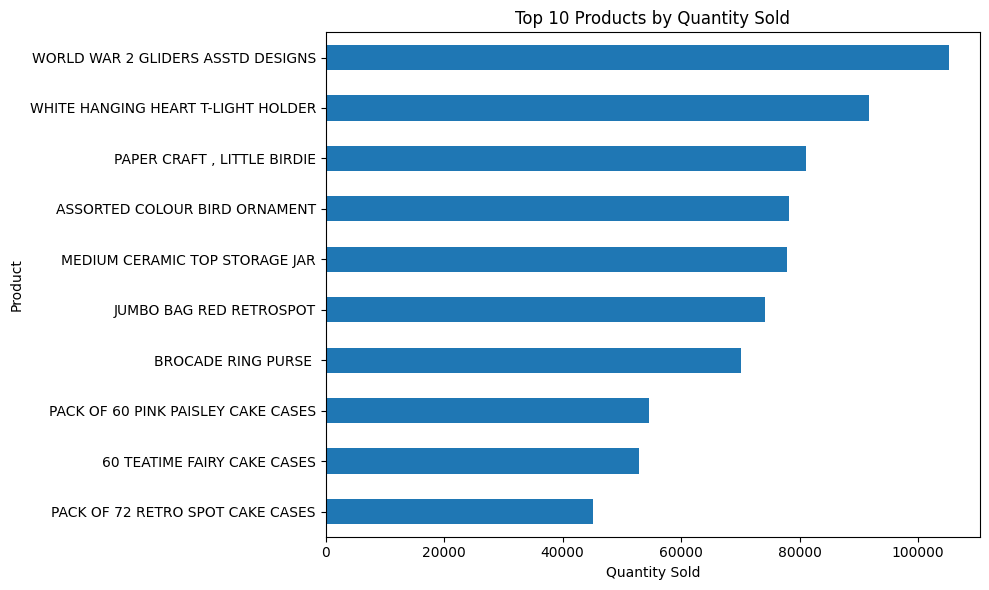

In [66]:
plt.figure(figsize=(10, 6))

top_products_quantity.sort_values().plot(
    kind='barh'
)

plt.title('Top 10 Products by Quantity Sold')
plt.xlabel('Quantity Sold')
plt.ylabel('Product')

plt.tight_layout()
plt.show()

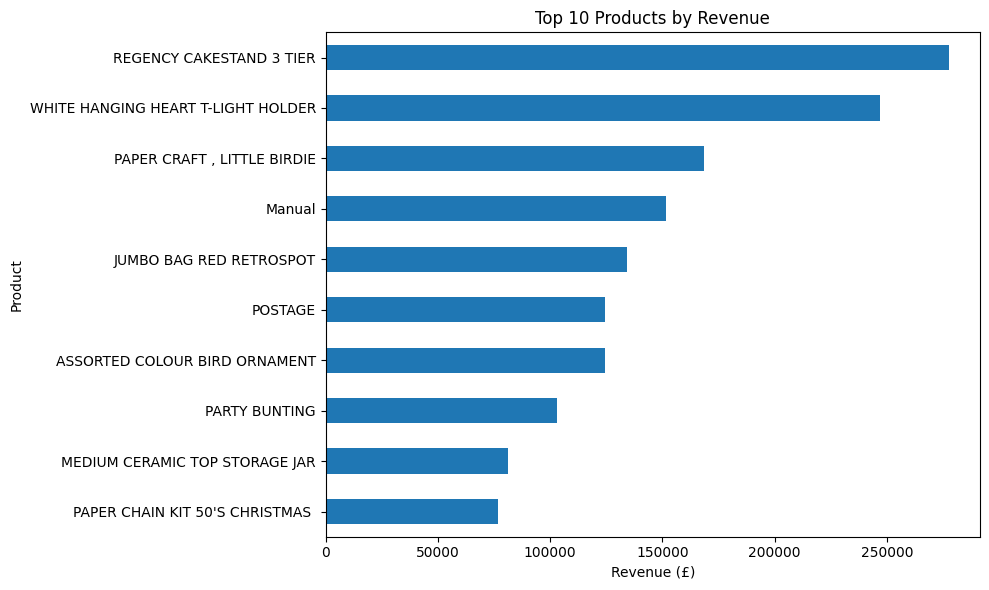

In [67]:
plt.figure(figsize=(10, 6))

top_products_revenue.sort_values().plot(
    kind='barh'
)

plt.title('Top 10 Products by Revenue')
plt.xlabel('Revenue (£)')
plt.ylabel('Product')

plt.tight_layout()
plt.show()

In [68]:
print("TOP PRODUCTS BY QUANTITY")
print(top_products_quantity.index.tolist())

print("\nTOP PRODUCTS BY REVENUE")
print(top_products_revenue.index.tolist())

TOP PRODUCTS BY QUANTITY
['WORLD WAR 2 GLIDERS ASSTD DESIGNS', 'WHITE HANGING HEART T-LIGHT HOLDER', 'PAPER CRAFT , LITTLE BIRDIE', 'ASSORTED COLOUR BIRD ORNAMENT', 'MEDIUM CERAMIC TOP STORAGE JAR', 'JUMBO BAG RED RETROSPOT', 'BROCADE RING PURSE ', 'PACK OF 60 PINK PAISLEY CAKE CASES', '60 TEATIME FAIRY CAKE CASES', 'PACK OF 72 RETRO SPOT CAKE CASES']

TOP PRODUCTS BY REVENUE
['REGENCY CAKESTAND 3 TIER', 'WHITE HANGING HEART T-LIGHT HOLDER', 'PAPER CRAFT , LITTLE BIRDIE', 'Manual', 'JUMBO BAG RED RETROSPOT', 'POSTAGE', 'ASSORTED COLOUR BIRD ORNAMENT', 'PARTY BUNTING', 'MEDIUM CERAMIC TOP STORAGE JAR', "PAPER CHAIN KIT 50'S CHRISTMAS "]


In [69]:
country_revenue = (
    clean_df.groupby('Country')['Revenue']
    .sum()
    .sort_values(ascending=False)
)

print(country_revenue.head(10))

Country
United Kingdom    1.438923e+07
EIRE              6.165705e+05
Netherlands       5.540381e+05
Germany           4.250197e+05
France            3.487690e+05
Australia         1.692835e+05
Spain             1.083325e+05
Switzerland       1.000619e+05
Sweden            9.151582e+04
Denmark           6.858069e+04
Name: Revenue, dtype: float64


In [70]:
country_orders = (
    clean_df.groupby('Country')['Invoice']
    .nunique()
    .sort_values(ascending=False)
)

print(country_orders.head(10))

Country
United Kingdom    33541
Germany             789
France              614
EIRE                567
Netherlands         228
Spain               154
Belgium             149
Sweden              104
Australia            95
Portugal             93
Name: Invoice, dtype: int64


In [71]:
country_customers = (
    clean_df.groupby('Country')['Customer ID']
    .nunique()
    .sort_values(ascending=False)
)

print(country_customers.head(10))

Country
United Kingdom    5350
Germany            107
France              95
Spain               41
Belgium             29
Portugal            24
Switzerland         22
Netherlands         22
Sweden              19
Italy               17
Name: Customer ID, dtype: int64


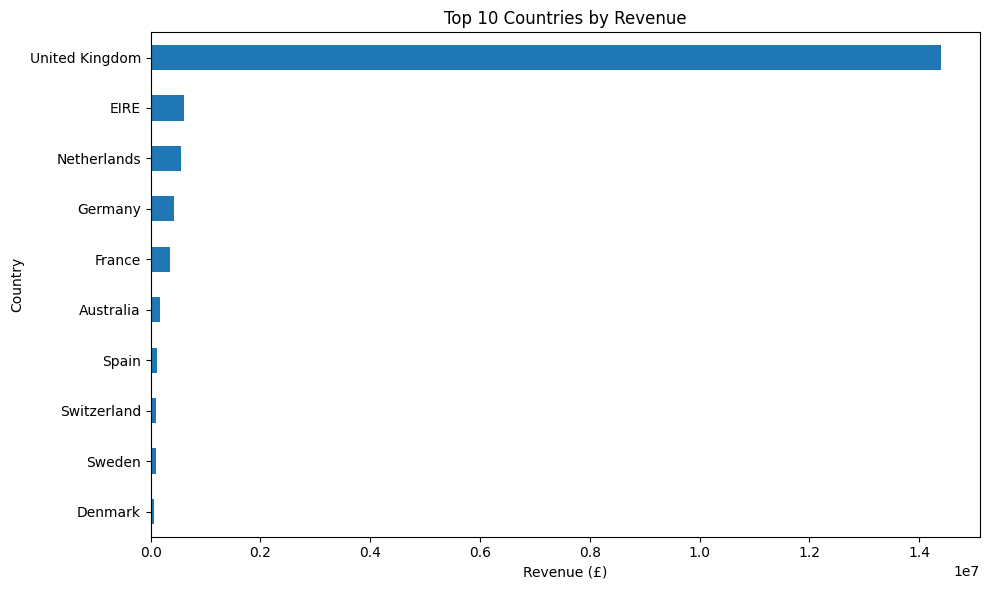

In [72]:
top_country_revenue = country_revenue.head(10)

plt.figure(figsize=(10, 6))

top_country_revenue.sort_values().plot(
    kind='barh'
)

plt.title('Top 10 Countries by Revenue')
plt.xlabel('Revenue (£)')
plt.ylabel('Country')

plt.tight_layout()
plt.show()

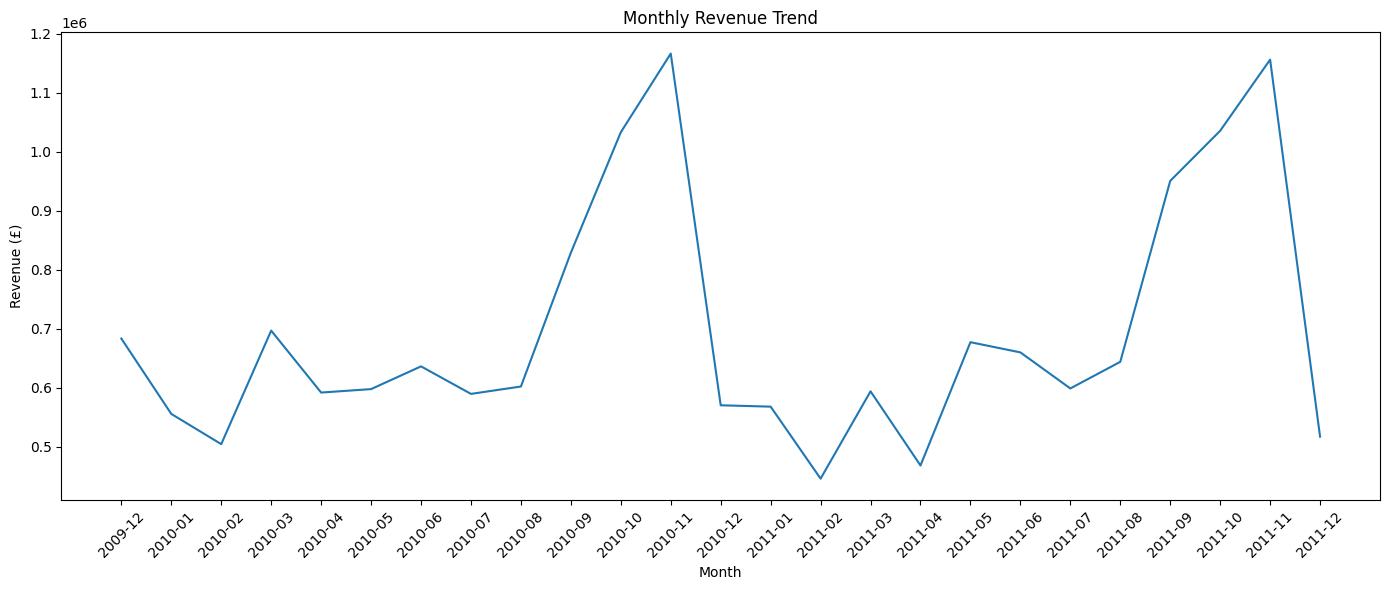

In [73]:
plt.figure(figsize=(14, 6))

plt.plot(
    monthly_revenue['YearMonth'].astype(str),
    monthly_revenue['Revenue']
)

plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue (£)')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [74]:
# Remove non-product entries for product analysis
product_df = clean_df[
    ~clean_df['Description'].str.upper().isin([
        'POSTAGE',
        'MANUAL'
    ])
].copy()

print("Original rows:", len(clean_df))
print("Product analysis rows:", len(product_df))

Original rows: 779425
Product analysis rows: 776941


In [75]:
top_products_revenue = (
    product_df.groupby('Description')['Revenue']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(top_products_revenue)

Description
REGENCY CAKESTAND 3 TIER              277656.25
WHITE HANGING HEART T-LIGHT HOLDER    247048.01
PAPER CRAFT , LITTLE BIRDIE           168469.60
JUMBO BAG RED RETROSPOT               134307.44
ASSORTED COLOUR BIRD ORNAMENT         124351.86
PARTY BUNTING                         103283.38
MEDIUM CERAMIC TOP STORAGE JAR         81416.73
PAPER CHAIN KIT 50'S CHRISTMAS         76598.18
CHILLI LIGHTS                          69084.30
JUMBO BAG STRAWBERRY                   64127.77
Name: Revenue, dtype: float64


In [76]:
top_products_quantity = (
    product_df.groupby('Description')['Quantity']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(top_products_quantity)

Description
WORLD WAR 2 GLIDERS ASSTD DESIGNS     105185
WHITE HANGING HEART T-LIGHT HOLDER     91757
PAPER CRAFT , LITTLE BIRDIE            80995
ASSORTED COLOUR BIRD ORNAMENT          78234
MEDIUM CERAMIC TOP STORAGE JAR         77916
JUMBO BAG RED RETROSPOT                74224
BROCADE RING PURSE                     70082
PACK OF 60 PINK PAISLEY CAKE CASES     54592
60 TEATIME FAIRY CAKE CASES            52828
PACK OF 72 RETRO SPOT CAKE CASES       45129
Name: Quantity, dtype: int64


In [77]:
country_revenue = (
    clean_df.groupby('Country')['Revenue']
    .sum()
    .sort_values(ascending=False)
)

total_country_revenue = country_revenue.sum()

uk_revenue = country_revenue['United Kingdom']

uk_percentage = (uk_revenue / total_country_revenue) * 100

print(f"UK Revenue: £{uk_revenue:,.2f}")
print(f"UK Revenue Contribution: {uk_percentage:.2f}%")

UK Revenue: £14,389,234.92
UK Revenue Contribution: 82.82%


In [78]:
analysis_date = clean_df['InvoiceDate'].max()

print("Analysis date:", analysis_date)

Analysis date: 2011-12-09 12:50:00


In [79]:
rfm = clean_df.groupby('Customer ID').agg(
    Recency=(
        'InvoiceDate',
        lambda x: (analysis_date - x.max()).days
    ),
    Frequency=(
        'Invoice',
        'nunique'
    ),
    Monetary=(
        'Revenue',
        'sum'
    )
)

rfm.head()

,Recency,Frequency,Monetary
Customer ID,,,
12346.0,325,12,77556.46
12347.0,1,8,4921.53
12348.0,74,5,2019.40
12349.0,18,4,4428.69
12350.0,309,1,334.40


In [80]:
rfm['R_Score'] = pd.qcut(
    rfm['Recency'].rank(method='first'),
    5,
    labels=[5, 4, 3, 2, 1]
)

rfm['F_Score'] = pd.qcut(
    rfm['Frequency'].rank(method='first'),
    5,
    labels=[1, 2, 3, 4, 5]
)

rfm['M_Score'] = pd.qcut(
    rfm['Monetary'].rank(method='first'),
    5,
    labels=[1, 2, 3, 4, 5]
)

In [81]:
rfm['RFM_Score'] = (
    rfm['R_Score'].astype(int) +
    rfm['F_Score'].astype(int) +
    rfm['M_Score'].astype(int)
)

rfm.head()

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
Customer ID,,,,,,,
12346.0,325,12,77556.46,2,5,5,12
12347.0,1,8,4921.53,5,4,5,14
12348.0,74,5,2019.40,3,4,4,11
12349.0,18,4,4428.69,5,3,5,13
12350.0,309,1,334.40,2,1,2,5


In [82]:
def segment_customer(row):
    score = row['RFM_Score']

    if score >= 13:
        return 'Champions'
    elif score >= 10:
        return 'Loyal Customers'
    elif score >= 7:
        return 'Potential Loyalists'
    elif score >= 5:
        return 'At Risk'
    else:
        return 'Lost Customers'


rfm['Segment'] = rfm.apply(segment_customer, axis=1)

rfm.head()

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Segment
Customer ID,,,,,,,,
12346.0,325,12,77556.46,2,5,5,12,Loyal Customers
12347.0,1,8,4921.53,5,4,5,14,Champions
12348.0,74,5,2019.40,3,4,4,11,Loyal Customers
12349.0,18,4,4428.69,5,3,5,13,Champions
12350.0,309,1,334.40,2,1,2,5,At Risk


In [83]:
segment_counts = (
    rfm['Segment']
    .value_counts()
)

print(segment_counts)

Segment
Potential Loyalists    1456
Loyal Customers        1356
Champions              1292
At Risk                 967
Lost Customers          807
Name: count, dtype: int64


In [84]:
print("TOP 10 PRODUCTS BY REVENUE")
print(top_products_revenue)

TOP 10 PRODUCTS BY REVENUE
Description
REGENCY CAKESTAND 3 TIER              277656.25
WHITE HANGING HEART T-LIGHT HOLDER    247048.01
PAPER CRAFT , LITTLE BIRDIE           168469.60
JUMBO BAG RED RETROSPOT               134307.44
ASSORTED COLOUR BIRD ORNAMENT         124351.86
PARTY BUNTING                         103283.38
MEDIUM CERAMIC TOP STORAGE JAR         81416.73
PAPER CHAIN KIT 50'S CHRISTMAS         76598.18
CHILLI LIGHTS                          69084.30
JUMBO BAG STRAWBERRY                   64127.77
Name: Revenue, dtype: float64


In [85]:
segment_revenue = (
    rfm.groupby('Segment')['Monetary']
    .sum()
    .sort_values(ascending=False)
)

print("Revenue by Customer Segment:")
print(segment_revenue)

Revenue by Customer Segment:
Segment
Champions              1.252514e+07
Loyal Customers        3.076329e+06
Potential Loyalists    1.241242e+06
At Risk                3.734874e+05
Lost Customers         1.586090e+05
Name: Monetary, dtype: float64


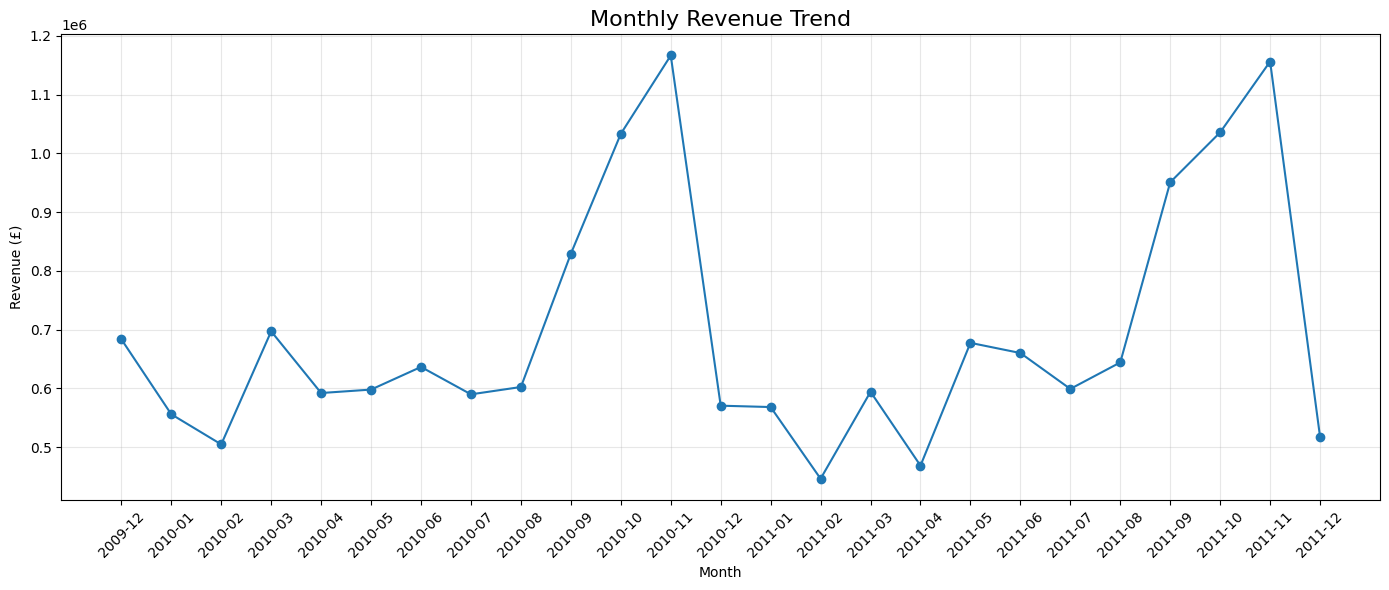

In [86]:
plt.figure(figsize=(14, 6))

plt.plot(
    monthly_revenue['YearMonth'].astype(str),
    monthly_revenue['Revenue'],
    marker='o'
)

plt.title('Monthly Revenue Trend', fontsize=16)
plt.xlabel('Month')
plt.ylabel('Revenue (£)')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

plt.tight_layout()

plt.savefig(
    '../images/monthly_revenue_trend.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

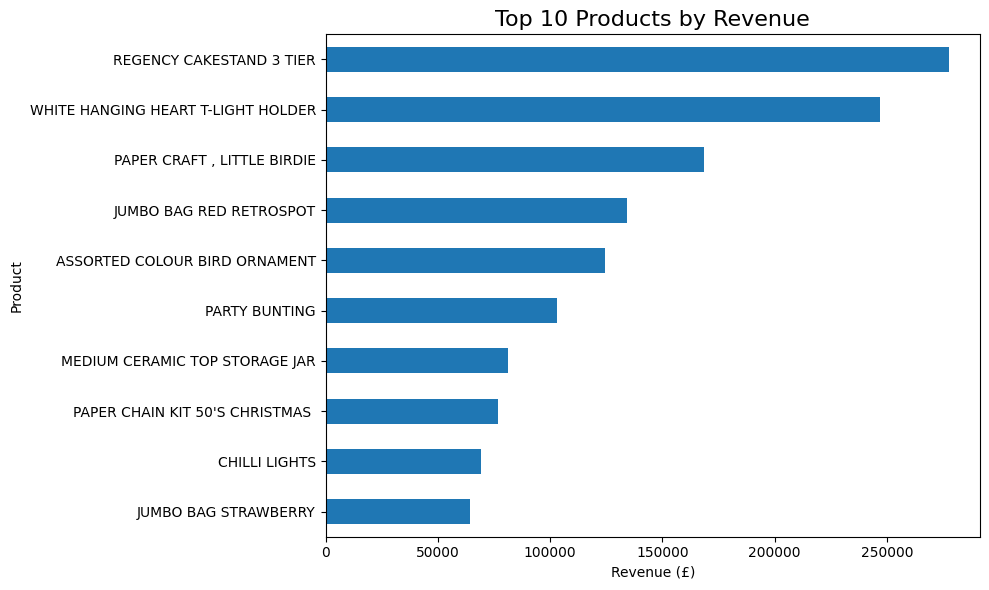

In [87]:
plt.figure(figsize=(10, 6))

top_products_revenue.sort_values().plot(kind='barh')

plt.title('Top 10 Products by Revenue', fontsize=16)
plt.xlabel('Revenue (£)')
plt.ylabel('Product')

plt.tight_layout()

plt.savefig(
    '../images/top_products_revenue.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

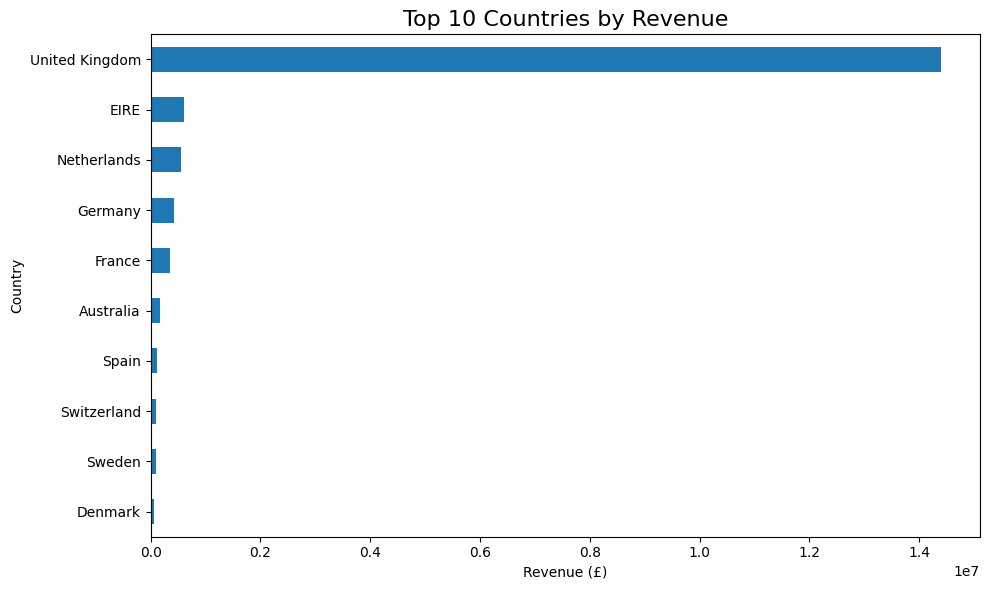

In [88]:
top_country_revenue = country_revenue.head(10)

plt.figure(figsize=(10, 6))

top_country_revenue.sort_values().plot(kind='barh')

plt.title('Top 10 Countries by Revenue', fontsize=16)
plt.xlabel('Revenue (£)')
plt.ylabel('Country')

plt.tight_layout()

plt.savefig(
    '../images/top_countries_revenue.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

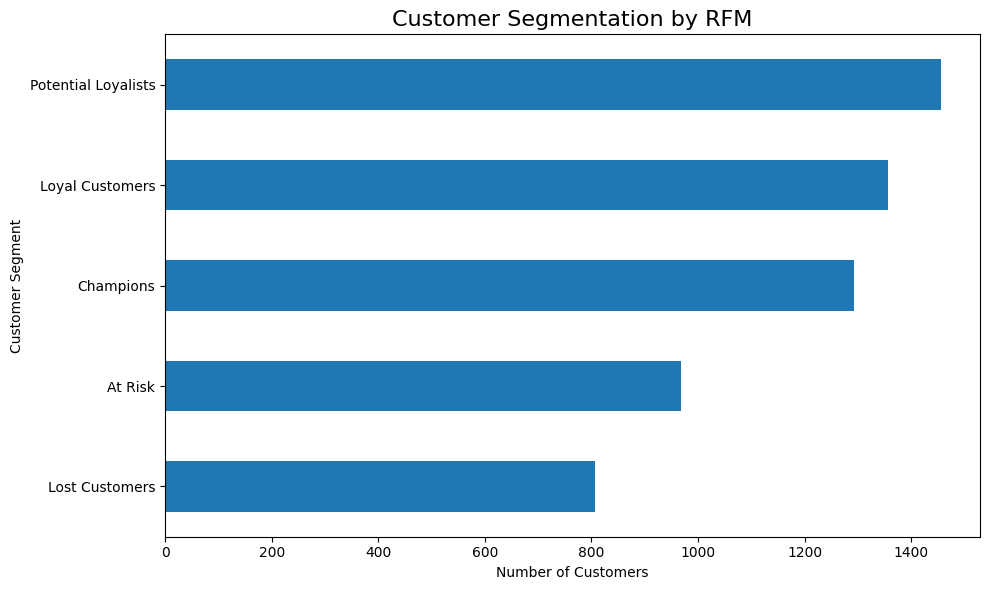

In [89]:
plt.figure(figsize=(10, 6))

segment_counts.sort_values().plot(kind='barh')

plt.title('Customer Segmentation by RFM', fontsize=16)
plt.xlabel('Number of Customers')
plt.ylabel('Customer Segment')

plt.tight_layout()

plt.savefig(
    '../images/customer_segments.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

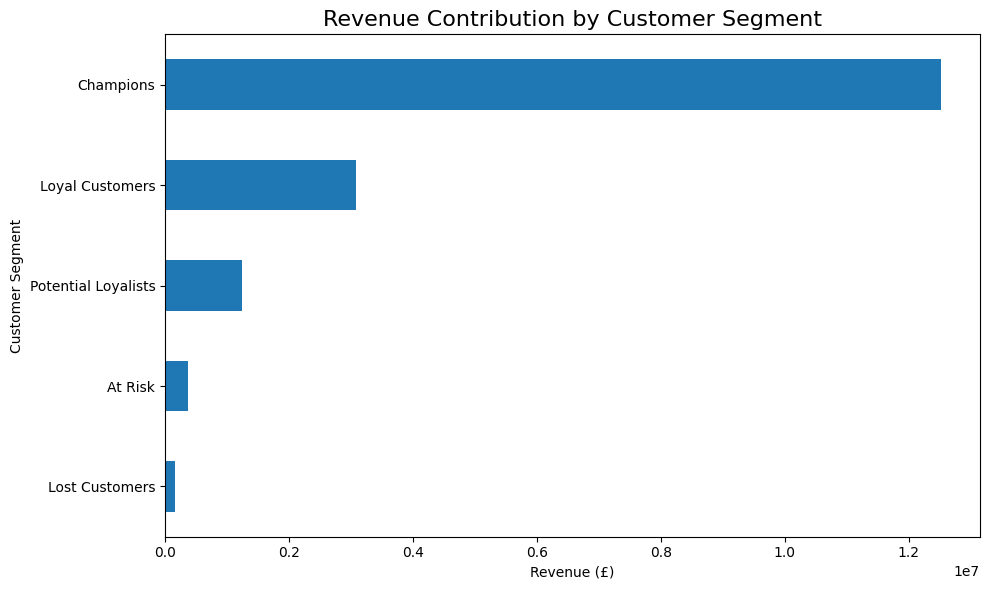

In [90]:
plt.figure(figsize=(10, 6))

segment_revenue.sort_values().plot(kind='barh')

plt.title('Revenue Contribution by Customer Segment', fontsize=16)
plt.xlabel('Revenue (£)')
plt.ylabel('Customer Segment')

plt.tight_layout()

plt.savefig(
    '../images/segment_revenue.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

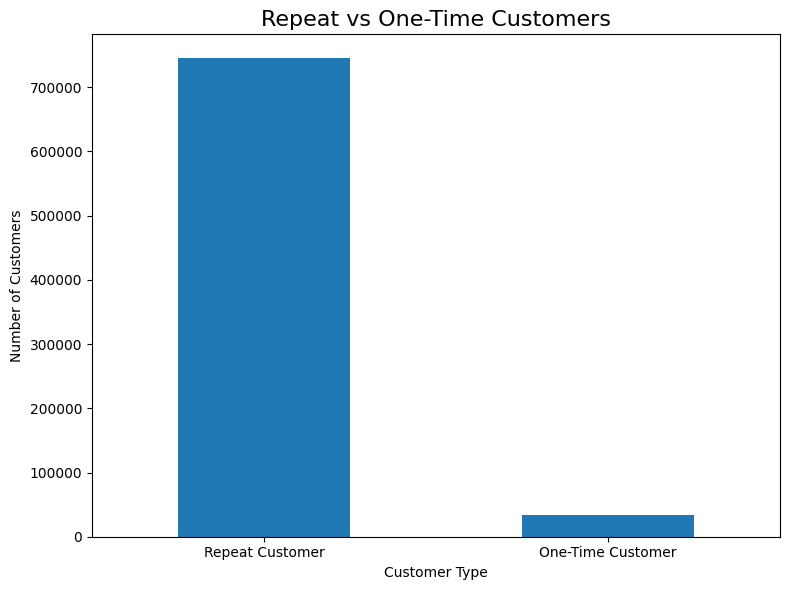

In [91]:
customer_type_counts = clean_df['Customer Type'].value_counts()

plt.figure(figsize=(8, 6))

customer_type_counts.plot(kind='bar')

plt.title('Repeat vs One-Time Customers', fontsize=16)
plt.xlabel('Customer Type')
plt.ylabel('Number of Customers')

plt.xticks(rotation=0)

plt.tight_layout()

plt.savefig(
    '../images/repeat_vs_onetime_customers.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

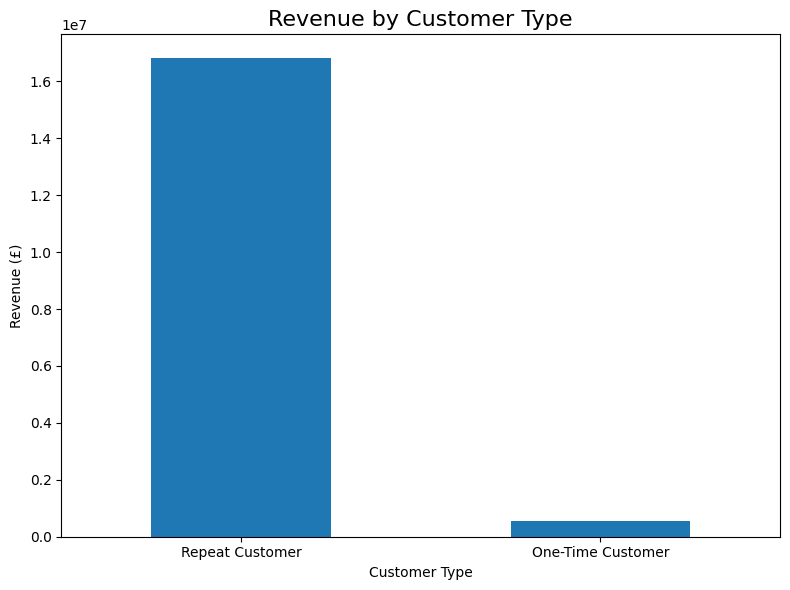

In [92]:
plt.figure(figsize=(8, 6))

revenue_by_customer_type.plot(kind='bar')

plt.title('Revenue by Customer Type', fontsize=16)
plt.xlabel('Customer Type')
plt.ylabel('Revenue (£)')

plt.xticks(rotation=0)

plt.tight_layout()

plt.savefig(
    '../images/revenue_by_customer_type.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [93]:
top_10_revenue_share = top_10_revenue_percentage

print(f"Top 10% customer revenue share: {top_10_revenue_share:.2f}%")
print(f"Remaining 90% revenue share: {100 - top_10_revenue_share:.2f}%")

Top 10% customer revenue share: 63.90%
Remaining 90% revenue share: 36.10%


In [94]:
at_risk_customers = segment_counts.get('At Risk', 0)
lost_customers = segment_counts.get('Lost Customers', 0)

at_risk_lost = at_risk_customers + lost_customers

at_risk_lost_percentage = (
    at_risk_lost / total_customers
) * 100

at_risk_lost_revenue = (
    segment_revenue.get('At Risk', 0) +
    segment_revenue.get('Lost Customers', 0)
)

at_risk_lost_revenue_percentage = (
    at_risk_lost_revenue /
    segment_revenue.sum()
) * 100

print("At Risk + Lost customers:", at_risk_lost)
print(f"Customer share: {at_risk_lost_percentage:.2f}%")
print(f"Revenue from these customers: £{at_risk_lost_revenue:,.2f}")
print(f"Revenue share: {at_risk_lost_revenue_percentage:.2f}%")

At Risk + Lost customers: 1774
Customer share: 30.18%
Revenue from these customers: £532,096.41
Revenue share: 3.06%


In [95]:
for year in [2010, 2011]:
    year_data = monthly_revenue[
        monthly_revenue['YearMonth'].astype(str).str.startswith(str(year))
    ].copy()
    
    year_data['MonthNum'] = (
        year_data['YearMonth'].astype(str).str[-2:].astype(int)
    )
    
    sep_revenue = year_data.loc[
        year_data['MonthNum'] == 9, 'Revenue'
    ].sum()
    
    nov_revenue = year_data.loc[
        year_data['MonthNum'] == 11, 'Revenue'
    ].sum()
    
    growth = ((nov_revenue - sep_revenue) / sep_revenue) * 100
    
    print(f"{year}: September → November growth = {growth:.2f}%")

2010: September → November growth = 40.70%
2011: September → November growth = 21.62%


In [96]:
international_revenue_share = 100 - uk_percentage

print(f"UK revenue share: {uk_percentage:.2f}%")
print(f"International revenue share: {international_revenue_share:.2f}%")

UK revenue share: 82.82%
International revenue share: 17.18%


In [97]:
insights = pd.DataFrame({
    'Finding': [
        'High repeat customer rate',
        'Revenue concentration among top customers',
        'Strong seasonal revenue pattern',
        'High UK revenue concentration',
        'Champions dominate revenue',
        'Large inactive customer segment'
    ],
    
    'Evidence': [
        f'{repeat_customer_rate:.2f}% of customers are repeat customers',
        f'Top 10% of customers generate {top_10_revenue_share:.2f}% of revenue',
        'Revenue peaks consistently around September-November',
        f'UK contributes {uk_percentage:.2f}% of total revenue',
        f'Champions contribute {segment_revenue["Champions"] / segment_revenue.sum() * 100:.2f}% of revenue',
        f'{at_risk_lost_percentage:.2f}% of customers are At Risk or Lost'
    ]
})

insights

,Finding,Evidence
0,High repeat customer rate,72.39% of customers are repeat customers
1,Revenue concentration among top customers,Top 10% of customers generate 63.90% of revenue
2,Strong seasonal revenue pattern,Revenue peaks consistently around September-No...
3,High UK revenue concentration,UK contributes 82.82% of total revenue
4,Champions dominate revenue,Champions contribute 72.09% of revenue
5,Large inactive customer segment,30.18% of customers are At Risk or Lost


In [98]:
segment_summary = pd.DataFrame({
    'Customers': rfm['Segment'].value_counts(),
    'Revenue': segment_revenue
})

segment_summary['Revenue_Percentage'] = (
    segment_summary['Revenue'] /
    segment_summary['Revenue'].sum() * 100
)

segment_summary

,Customers,Revenue,Revenue_Percentage
Segment,,,
At Risk,967,3.734874e+05,2.149592
Champions,1292,1.252514e+07,72.087933
Lost Customers,807,1.586090e+05,0.912868
Loyal Customers,1356,3.076329e+06,17.705689
Potential Loyalists,1456,1.241242e+06,7.143917


In [99]:
segment_percentage = (
    segment_counts / len(rfm) * 100
).round(2)

print(segment_percentage)

Segment
Potential Loyalists    24.77
Loyal Customers        23.07
Champions              21.98
At Risk                16.45
Lost Customers         13.73
Name: count, dtype: float64


In [100]:
segment_revenue = (
    rfm.groupby('Segment')['Monetary']
    .sum()
    .sort_values(ascending=False)
)

print(segment_revenue)

Segment
Champions              1.252514e+07
Loyal Customers        3.076329e+06
Potential Loyalists    1.241242e+06
At Risk                3.734874e+05
Lost Customers         1.586090e+05
Name: Monetary, dtype: float64


In [101]:
segment_summary = pd.DataFrame({
    'Customers': segment_counts,
    'Revenue': segment_revenue
})

segment_summary['Revenue_Percentage'] = (
    segment_summary['Revenue'] /
    segment_summary['Revenue'].sum() * 100
)

segment_summary

,Customers,Revenue,Revenue_Percentage
Segment,,,
At Risk,967,3.734874e+05,2.149592
Champions,1292,1.252514e+07,72.087933
Lost Customers,807,1.586090e+05,0.912868
Loyal Customers,1356,3.076329e+06,17.705689
Potential Loyalists,1456,1.241242e+06,7.143917


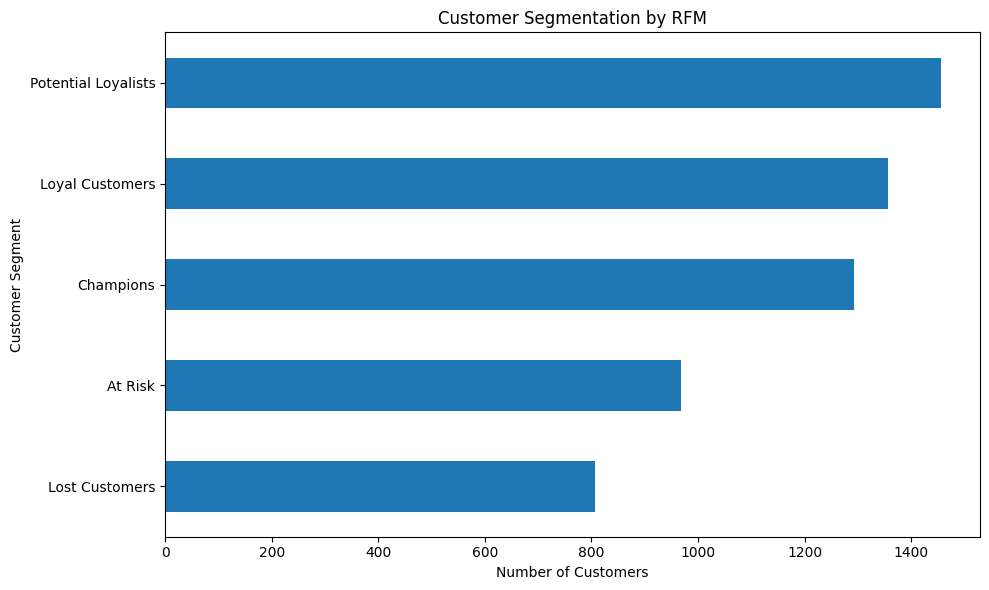

In [102]:
plt.figure(figsize=(10, 6))

segment_counts.sort_values().plot(
    kind='barh'
)

plt.title('Customer Segmentation by RFM')
plt.xlabel('Number of Customers')
plt.ylabel('Customer Segment')

plt.tight_layout()
plt.show()

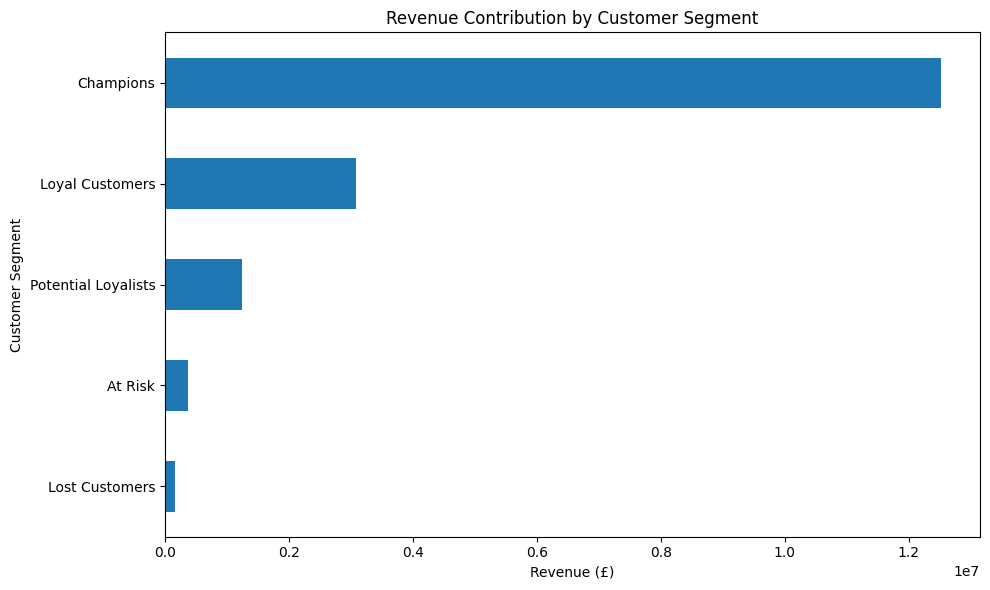

In [103]:
plt.figure(figsize=(10, 6))

segment_revenue.sort_values().plot(
    kind='barh'
)

plt.title('Revenue Contribution by Customer Segment')
plt.xlabel('Revenue (£)')
plt.ylabel('Customer Segment')

plt.tight_layout()
plt.show()

In [104]:
highest_month = monthly_revenue.loc[
    monthly_revenue['Revenue'].idxmax()
]

lowest_month = monthly_revenue.loc[
    monthly_revenue['Revenue'].idxmin()
]

print("Highest Revenue Month:")
print(highest_month)

print("\nLowest Revenue Month:")
print(lowest_month)

Highest Revenue Month:
YearMonth        2010-11
Revenue      1166460.022
Name: 11, dtype: object

Lowest Revenue Month:
YearMonth      2011-02
Revenue      446084.92
Name: 14, dtype: object


In [105]:
monthly_orders = (
    clean_df.groupby('YearMonth')['Invoice']
    .nunique()
    .reset_index(name='Orders')
)

monthly_orders

,YearMonth,Orders
0,2009-12,1512
1,2010-01,1011
2,2010-02,1104
3,2010-03,1524
4,2010-04,1329
5,2010-05,1377
6,2010-06,1497
7,2010-07,1381
8,2010-08,1293
9,2010-09,1689


In [106]:
monthly_performance = monthly_revenue.merge(
    monthly_orders,
    on='YearMonth'
)

monthly_performance['Average_Order_Value'] = (
    monthly_performance['Revenue'] /
    monthly_performance['Orders']
)

monthly_performance

,YearMonth,Revenue,Orders,Average_Order_Value
0,2009-12,683504.010,1512,452.052917
1,2010-01,555802.672,1011,549.755363
2,2010-02,504558.956,1104,457.028040
3,2010-03,696978.471,1524,457.334955
4,2010-04,591982.002,1329,445.434163
5,2010-05,597833.380,1377,434.156412
6,2010-06,636371.130,1497,425.097615
7,2010-07,589736.170,1381,427.035605
8,2010-08,602224.600,1293,465.757618
9,2010-09,829013.951,1689,490.831232


In [107]:
clean_df.info()

<class 'pandas.DataFrame'>
Index: 779425 entries, 0 to 1067370
Data columns (total 14 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   Invoice        779425 non-null  object        
 1   StockCode      779425 non-null  object        
 2   Description    779425 non-null  object        
 3   Quantity       779425 non-null  int64         
 4   InvoiceDate    779425 non-null  datetime64[us]
 5   Price          779425 non-null  float64       
 6   Customer ID    779425 non-null  float64       
 7   Country        779425 non-null  str           
 8   Revenue        779425 non-null  float64       
 9   Year           779425 non-null  int32         
 10  Month          779425 non-null  int32         
 11  YearMonth      779425 non-null  period[M]     
 12  DayOfWeek      779425 non-null  str           
 13  Customer Type  779425 non-null  str           
dtypes: datetime64[us](1), float64(3), int32(2), int64(1), object(3), pe